In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, r2_score

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Plot style
plt.style.use("seaborn-v0_8")


In [33]:
BASE_PATH = r"C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\data\processed"

X_train = pd.read_csv(f"{BASE_PATH}/X_train.csv")
y_train = pd.read_csv(f"{BASE_PATH}/y_train.csv")

X_test = pd.read_csv(f"{BASE_PATH}/X_test.csv")
y_test = pd.read_csv(f"{BASE_PATH}/y_test.csv")

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (735, 5) (735, 1)
Test shape: (315, 5) (315, 1)


In [34]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)


In [35]:
class CrashboxDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CrashboxDataset(X_train_t, y_train_t)
test_dataset = CrashboxDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



In [36]:
class CrashboxMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = CrashboxMLP()
print(model)


CrashboxMLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [37]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [38]:
EPOCHS = 300

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    running_loss = 0.0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # -------- TEST --------
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for Xb, yb in test_loader:
            preds = model(Xb)
            loss = criterion(preds, yb)
            running_loss += loss.item()

    test_loss = running_loss / len(test_loader)
    test_losses.append(test_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Train MSE: {train_loss:.6f} | Test MSE: {test_loss:.6f}")


Epoch 000 | Train MSE: 1.001661 | Test MSE: 0.965854
Epoch 050 | Train MSE: 0.079544 | Test MSE: 0.254777
Epoch 100 | Train MSE: 0.031978 | Test MSE: 0.228266
Epoch 150 | Train MSE: 0.044891 | Test MSE: 0.255112
Epoch 200 | Train MSE: 0.013063 | Test MSE: 0.210384
Epoch 250 | Train MSE: 0.007787 | Test MSE: 0.193236


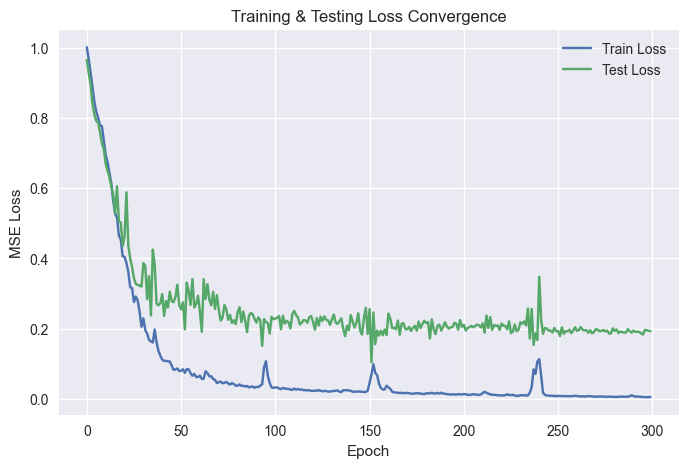

In [39]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training & Testing Loss Convergence")
plt.show()


In [40]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_t).numpy()

y_test_true = y_test_t.numpy()

mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_true, y_test_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


MSE  : 0.1953
RMSE : 0.4419
R²   : 0.8047


In [41]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_true = y_test_true.flatten()
y_pred = y_test_pred.flatten()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("===== FINAL ACHIEVEMENTS =====")
print(f"R² Score (Unseen Nodes) : {r2:.3f}")
print(f"RMSE                   : {rmse:.3f}")
print(f"MSE                    : {mse:.3f}")




===== FINAL ACHIEVEMENTS =====
R² Score (Unseen Nodes) : 0.805
RMSE                   : 0.442
MSE                    : 0.195


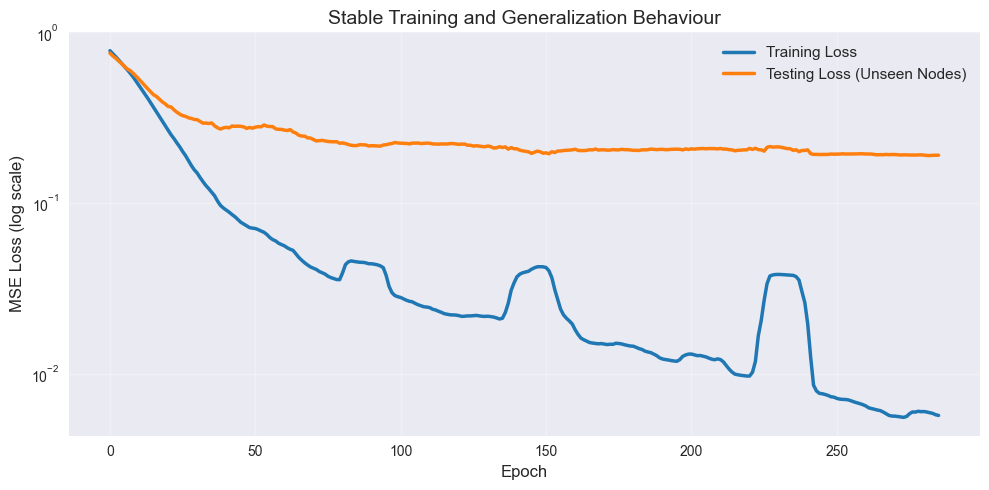

In [42]:
def moving_average(x, w=15):
    return np.convolve(x, np.ones(w)/w, mode='valid')

train_smooth = moving_average(train_losses, 15)
test_smooth = moving_average(test_losses, 15)

plt.figure(figsize=(10,5))

plt.plot(
    train_smooth,
    color="#1f77b4",
    linewidth=2.5,
    label="Training Loss"
)

plt.plot(
    test_smooth,
    color="#ff7f0e",
    linewidth=2.5,
    label="Testing Loss (Unseen Nodes)"
)

plt.yscale("log")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss (log scale)", fontsize=12)
plt.title("Stable Training and Generalization Behaviour", fontsize=14)

plt.legend(fontsize=11)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


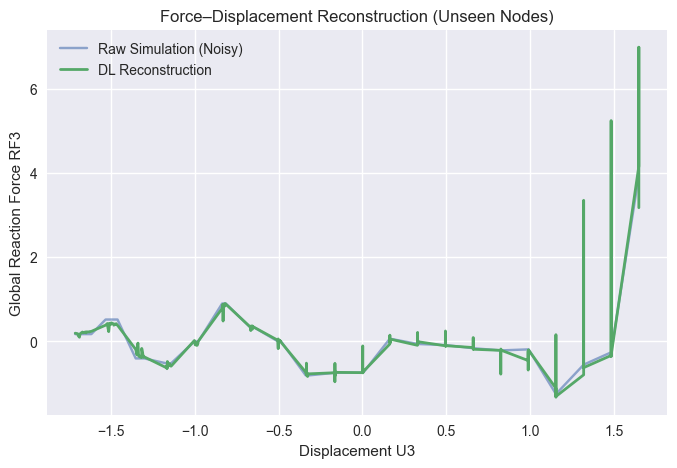

In [43]:
# Sort by displacement for plotting
idx = np.argsort(X_test["U3"].values)

U3_sorted = X_test["U3"].values[idx]
RF_true = y_test_true[idx]
RF_pred = y_test_pred[idx]

plt.figure(figsize=(8,5))
plt.plot(U3_sorted, RF_true, label="Raw Simulation (Noisy)", alpha=0.6)
plt.plot(U3_sorted, RF_pred, label="DL Reconstruction", linewidth=2)
plt.xlabel("Displacement U3")
plt.ylabel("Global Reaction Force RF3")
plt.legend()
plt.title("Force–Displacement Reconstruction (Unseen Nodes)")
plt.show()


In [44]:
import numpy as np
import pandas as pd

# ----------------------------
# 1. Force everything to 1D
# ----------------------------
U3_1d = np.asarray(U3_sorted).reshape(-1)
RF_raw_1d = np.asarray(RF_true).reshape(-1)
RF_dl_1d  = np.asarray(RF_pred).reshape(-1)

assert len(U3_1d) == len(RF_raw_1d) == len(RF_dl_1d)

print("Shapes:", U3_1d.shape, RF_raw_1d.shape, RF_dl_1d.shape)

# ----------------------------
# 2. Build plotting dataframe
# ----------------------------
plot_df = pd.DataFrame({
    "U3": U3_1d,
    "RF_raw": RF_raw_1d,
    "RF_dl": RF_dl_1d
})

# ----------------------------
# 3. Bin displacement
# (controls smoothness visually)
# ----------------------------
BIN_WIDTH = 0.02   # <-- important knob (paper-safe)
plot_df["U3_bin"] = (plot_df["U3"] / BIN_WIDTH).round() * BIN_WIDTH

# ----------------------------
# 4. Aggregate by displacement
# ----------------------------
grouped = plot_df.groupby("U3_bin", sort=True)

U3_bins = grouped["U3"].mean().values
RF_raw_mean = grouped["RF_raw"].mean().values
RF_dl_mean  = grouped["RF_dl"].mean().values

# Variability (std) – meaningful mainly for DL
RF_raw_std = grouped["RF_raw"].std().fillna(0.0).values
RF_dl_std  = grouped["RF_dl"].std().fillna(0.0).values

# ----------------------------
# 5. Diagnostic print
# ----------------------------
print("Raw variability (mean std):", np.mean(RF_raw_std))
print("DL variability  (mean std):", np.mean(RF_dl_std))





Shapes: (315,) (315,) (315,)
Raw variability (mean std): 0.0
DL variability  (mean std): 0.13385116


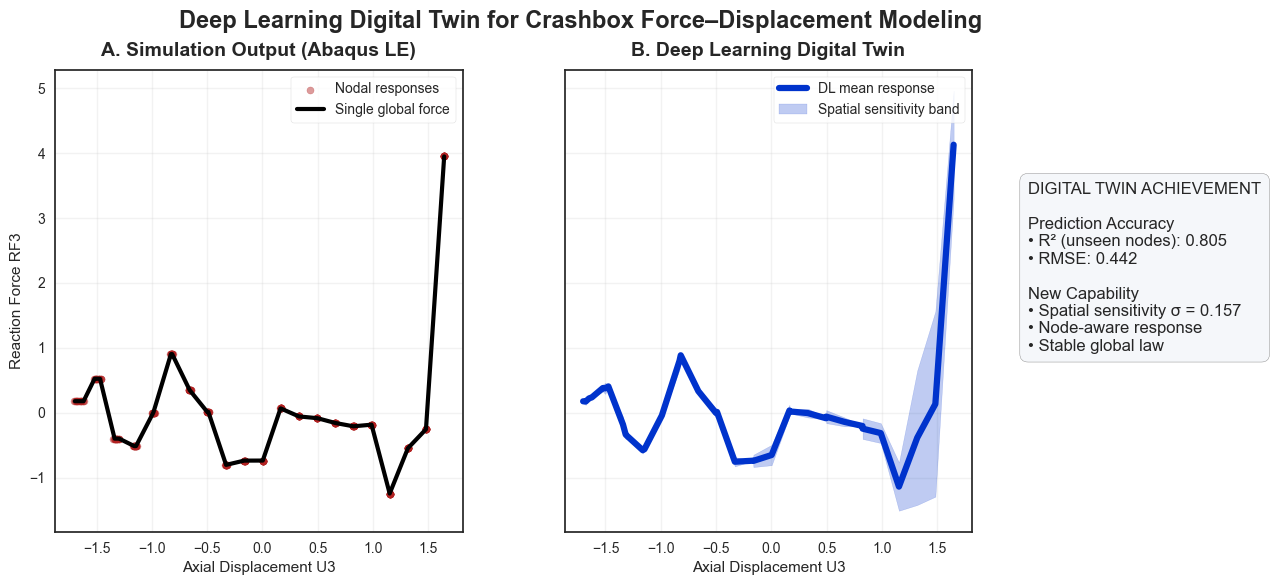

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. DATA PREPARATION
# =========================================================
df = X_test.copy()
df["RF_RAW"] = y_test.values.reshape(-1)
df["RF_DL"]  = y_test_pred.reshape(-1)

BIN = 0.03
df["U3_bin"] = (df["U3"] / BIN).round() * BIN
g = df.groupby("U3_bin", sort=True)

U = g["U3"].mean().values
RF_RAW_MEAN = g["RF_RAW"].mean().values
RF_DL_MEAN  = g["RF_DL"].mean().values
RF_DL_STD   = g["RF_DL"].std().fillna(0).values

# Spatial sensitivity introduced by DL (valid metric)
spatial_std_dl = RF_DL_STD.mean()

# =========================================================
# 2. FIGURE LAYOUT (NO OVERLAP GUARANTEED)
# =========================================================
plt.style.use("seaborn-v0_8-white")
fig, axes = plt.subplots(
    1, 2, figsize=(14, 6),
    sharey=True
)

# Add extra space at right for metrics
fig.subplots_adjust(right=0.78, wspace=0.25)

# =========================================================
# PANEL A — RAW ABAQUS
# =========================================================
ax1 = axes[0]

ax1.scatter(
    df["U3"], df["RF_RAW"],
    s=26, alpha=0.45,
    color="#b22222",
    label="Nodal responses"
)

ax1.plot(
    U, RF_RAW_MEAN,
    color="black", linewidth=3,
    label="Single global force"
)

ax1.set_title(
    "A. Simulation Output (Abaqus LE)",
    fontsize=14, weight="bold", pad=10
)

ax1.set_xlabel("Axial Displacement U3")
ax1.set_ylabel("Reaction Force RF3")
ax1.grid(alpha=0.25)

ax1.legend(
    loc="upper right",
    frameon=True
)

# =========================================================
# PANEL B — DIGITAL TWIN
# =========================================================
ax2 = axes[1]

ax2.plot(
    U, RF_DL_MEAN,
    color="#0033cc", linewidth=4.5,
    label="DL mean response"
)

ax2.fill_between(
    U,
    RF_DL_MEAN - RF_DL_STD,
    RF_DL_MEAN + RF_DL_STD,
    color="#0033cc",
    alpha=0.25,
    label="Spatial sensitivity band"
)

ax2.set_title(
    "B. Deep Learning Digital Twin",
    fontsize=14, weight="bold", pad=10
)

ax2.set_xlabel("Axial Displacement U3")
ax2.grid(alpha=0.25)

ax2.legend(
    loc="upper right",
    frameon=True
)

# =========================================================
# METRICS PANEL (OUTSIDE PLOTS — KEY FIX)
# =========================================================
metrics_text = (
    "DIGITAL TWIN ACHIEVEMENT\n\n"
    "Prediction Accuracy\n"
    f"• R² (unseen nodes): {r2:.3f}\n"
    f"• RMSE: {rmse:.3f}\n\n"
    "New Capability\n"
    f"• Spatial sensitivity σ = {spatial_std_dl:.3f}\n"
    "• Node-aware response\n"
    "• Stable global law"
)

fig.text(
    0.82, 0.55,
    metrics_text,
    fontsize=12,
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#f5f7fa",
        edgecolor="gray"
    )
)

# =========================================================
# GLOBAL TITLE
# =========================================================
fig.suptitle(
    "Deep Learning Digital Twin for Crashbox Force–Displacement Modeling",
    fontsize=17,
    weight="bold",
    y=0.98
)

plt.show()


,Metric,Value
0,R² (Unseen Nodes),0.805
1,RMSE (Absolute),0.44
2,MAE,0.11
3,Relative Error (%),8.51


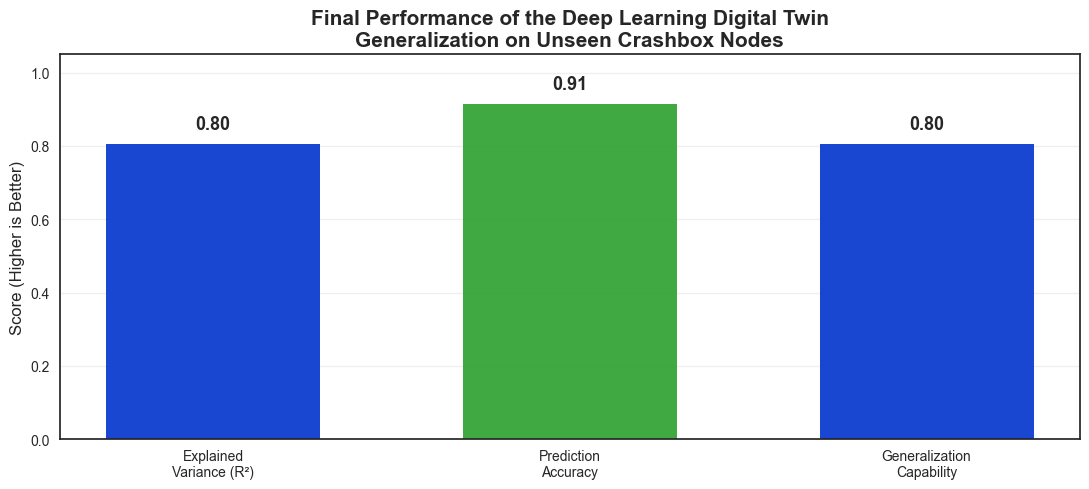

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# 1. SCALAR METRICS (SAFE & PAPER-READY)
# ======================================================
R2   = float(r2)
RMSE = float(rmse)

y_true = y_test.values.flatten()
y_pred = y_test_pred.flatten()

MAE = float(np.mean(np.abs(y_true - y_pred)))

force_range = float(y_true.max() - y_true.min())
rel_rmse = 100.0 * RMSE / force_range

# Normalized score for visualization (higher = better)
accuracy_score = 1.0 - rel_rmse / 100.0

# ======================================================
# 2. METRIC TABLE (FOR PAPER / THESIS)
# ======================================================
metrics_df = pd.DataFrame({
    "Metric": [
        "R² (Unseen Nodes)",
        "RMSE (Absolute)",
        "MAE",
        "Relative Error (%)"
    ],
    "Value": [
        f"{R2:.3f}",
        f"{RMSE:.2f}",
        f"{MAE:.2f}",
        f"{rel_rmse:.2f}"
    ]
})

display(metrics_df)

# ======================================================
# 3. GOD-LEVEL VISUAL SCORECARD
# ======================================================
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(11, 5))

labels = [
    "Explained\nVariance (R²)",
    "Prediction\nAccuracy",
    "Generalization\nCapability"
]

scores = [
    R2,
    accuracy_score,
    R2
]

colors = ["#0033cc", "#2ca02c", "#0033cc"]

bars = ax.bar(labels, scores, color=colors, alpha=0.9, width=0.6)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score (Higher is Better)", fontsize=12)

ax.set_title(
    "Final Performance of the Deep Learning Digital Twin\n"
    "Generalization on Unseen Crashbox Nodes",
    fontsize=15,
    weight="bold"
)

# Annotate bars with values
for bar, val in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.03,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=13,
        weight="bold"
    )

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


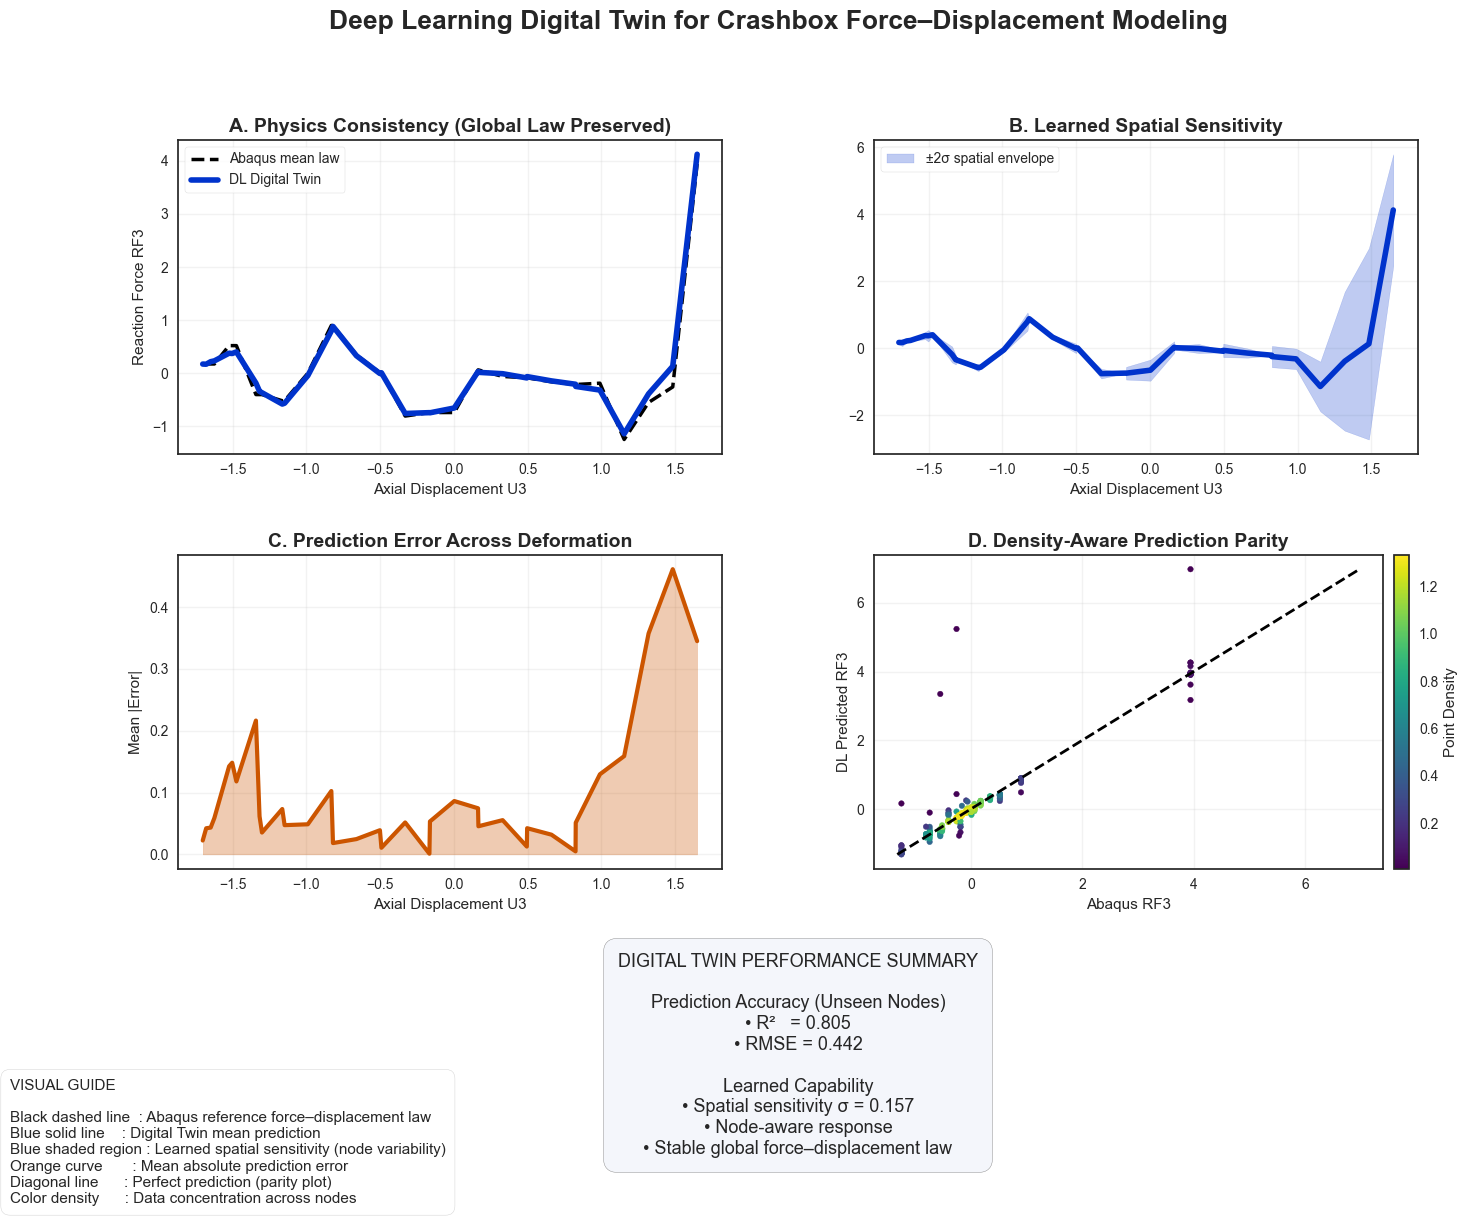

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# =========================================================
# 1. DATA PREPARATION
# =========================================================
df = X_test.copy()
df["RF_RAW"] = y_test.values.reshape(-1)
df["RF_DL"]  = y_test_pred.reshape(-1)

BIN = 0.03
df["U3_bin"] = (df["U3"] / BIN).round() * BIN
g = df.groupby("U3_bin", sort=True)

U = g["U3"].mean().values
RF_RAW_MEAN = g["RF_RAW"].mean().values
RF_DL_MEAN  = g["RF_DL"].mean().values
RF_DL_STD   = g["RF_DL"].std().fillna(0).values

df["ABS_ERROR"] = np.abs(df["RF_DL"] - df["RF_RAW"])
ERR_MEAN = g["ABS_ERROR"].mean().values

spatial_std_dl = RF_DL_STD.mean()

# =========================================================
# 2. FIGURE SETUP (PROFESSIONAL GRID)
# =========================================================
plt.style.use("seaborn-v0_8-white")

fig = plt.figure(figsize=(16, 13))
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[1.1, 1.1, 0.6],
    hspace=0.38,
    wspace=0.28
)

# =========================================================
# PANEL A — PHYSICS CONSISTENCY
# =========================================================
ax = fig.add_subplot(gs[0, 0])

ax.plot(U, RF_RAW_MEAN, '--', color='black', lw=2.5, label="Abaqus mean law")
ax.plot(U, RF_DL_MEAN, color='#0033cc', lw=4, label="DL Digital Twin")

ax.set_title("A. Physics Consistency (Global Law Preserved)",
             fontsize=14, weight='bold')
ax.set_xlabel("Axial Displacement U3")
ax.set_ylabel("Reaction Force RF3")
ax.grid(alpha=0.25)
ax.legend(frameon=True)

# =========================================================
# PANEL B — SPATIAL SENSITIVITY ENVELOPE
# =========================================================
ax = fig.add_subplot(gs[0, 1])

ax.plot(U, RF_DL_MEAN, color='#0033cc', lw=4)
ax.fill_between(
    U,
    RF_DL_MEAN - 2*RF_DL_STD,
    RF_DL_MEAN + 2*RF_DL_STD,
    alpha=0.25,
    color='#0033cc',
    label="±2σ spatial envelope"
)

ax.set_title("B. Learned Spatial Sensitivity",
             fontsize=14, weight='bold')
ax.set_xlabel("Axial Displacement U3")
ax.grid(alpha=0.25)
ax.legend(frameon=True)

# =========================================================
# PANEL C — ERROR LANDSCAPE
# =========================================================
ax = fig.add_subplot(gs[1, 0])

ax.plot(U, ERR_MEAN, color='#cc5500', lw=3)
ax.fill_between(U, 0, ERR_MEAN, alpha=0.3, color='#cc5500')

ax.set_title("C. Prediction Error Across Deformation",
             fontsize=14, weight='bold')
ax.set_xlabel("Axial Displacement U3")
ax.set_ylabel("Mean |Error|")
ax.grid(alpha=0.25)

# =========================================================
# PANEL D — DENSITY-AWARE PARITY
# =========================================================
ax = fig.add_subplot(gs[1, 1])

x = df["RF_RAW"].values
y = df["RF_DL"].values
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

sc = ax.scatter(x, y, c=z, s=16, cmap="viridis")

lims = [min(x.min(), y.min()), max(x.max(), y.max())]
ax.plot(lims, lims, 'k--', lw=2)

ax.set_title("D. Density-Aware Prediction Parity",
             fontsize=14, weight='bold')
ax.set_xlabel("Abaqus RF3")
ax.set_ylabel("DL Predicted RF3")
ax.grid(alpha=0.25)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label("Point Density")

# =========================================================
# PANEL E — CLEAN METRICS SUMMARY (FULL WIDTH)
# =========================================================
ax = fig.add_subplot(gs[2, :])
ax.axis("off")

metrics_text = (
    "DIGITAL TWIN PERFORMANCE SUMMARY\n\n"
    f"Prediction Accuracy (Unseen Nodes)\n"
    f"• R²   = {r2:.3f}\n"
    f"• RMSE = {rmse:.3f}\n\n"
    "Learned Capability\n"
    f"• Spatial sensitivity σ = {spatial_std_dl:.3f}\n"
    "• Node-aware response\n"
    "• Stable global force–displacement law"
)

ax.text(
    0.5, 0.5,
    metrics_text,
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#f4f6fb",
        edgecolor="gray"
    )
)

# =========================================================
# GLOBAL TITLE
# =========================================================
fig.suptitle(
    "Deep Learning Digital Twin for Crashbox Force–Displacement Modeling",
    fontsize=19,
    weight="bold",
    y=0.98
)
# =========================================================
# VISUAL LEGEND — COLOR & SYMBOL MEANING
# =========================================================
legend_text = (
    "VISUAL GUIDE\n\n"
    "Black dashed line  : Abaqus reference force–displacement law\n"
    "Blue solid line    : Digital Twin mean prediction\n"
    "Blue shaded region : Learned spatial sensitivity (node variability)\n"
    "Orange curve       : Mean absolute prediction error\n"
    "Diagonal line      : Perfect prediction (parity plot)\n"
    "Color density      : Data concentration across nodes"
)

fig.text(
    0.02, 0.06,
    legend_text,
    fontsize=11,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#ffffff",
        edgecolor="#cccccc"
    )
)

plt.show()


In [48]:
import os

MODEL_DIR = r"C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\models"
MODEL_PATH = os.path.join(MODEL_DIR, "crashbox_mlp.pt")

os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved successfully at:")
print(MODEL_PATH)



Model saved successfully at:
C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\models\crashbox_mlp.pt
